In [ ]:
#CDSE

## Mengumpulkan data

In [2]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [openeo]2m5/6 [openeo]]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

# KOORDINAT BARU (SURABAYA & SIDOARJO)
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.42, -7.15], # West, North
            [112.42, -7.70], # West, South
            [112.91, -7.70], # East, South
            [112.91, -7.15], # East, North
            [112.42, -7.15]  # West, North (Menutup polygon)
        ]
    ],
    "type": "Polygon"
}

s5p_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-15", "2025-10-19"],
    spatial_extent={ # BOUNDING BOX BARU
        "west": 112.42,
        "south": -7.70,
        "east": 112.91,
        "north": -7.15
    },
    bands=["NO2"]
)

s5p_no2_daily = s5p_no2.aggregate_temporal_period(
    period="day",
    reducer="mean"
)

s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    geometries=aoi,
    reducer="mean"
)

# NAMA FILE DAN JUDUL BARU
job = s5p_no2.execute_batch(
    title="NO2 in Surabaya Sidoarjo", 
    outputfile="NO2_surabaya_sidoarjo.nc" # Nama file NetCDF diubah
)

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=TUJO-XWKS 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
0:00:00 Job 'j-2510261752524ba7855c505d221c5017': send 'start'
0:00:13 Job 'j-2510261752524ba7855c505d221c5017': created (progress 0%)
0:00:18 Job 'j-2510261752524ba7855c505d221c5017': queued (progress 0%)
0:00:25 Job 'j-2510261752524ba7855c505d221c5017': queued (progress 0%)
0:00:33 Job 'j-2510261752524ba7855c505d221c5017': queued (progress 0%)
0:00:43 Job 'j-2510261752524ba7855c505d221c5017': queued (progress 0%)
0:00:56 Job 'j-2510261752524ba7855c505d221c5017': queued (progress 0%)
0:01:12 Job 'j-2510261752524ba7855c505d221c5017': queued (progress 0%)
0:01:31 Job 'j-2510261752524ba7855c505d221c5017': running (progress N/A)
0:01:55 Job 'j-2510261752524ba7855c505d221c5017': running (progress N/A)
0:02:26 Job 'j-2510261752524ba7855c505d221c5017': running (progress N/A)
0:03:05 Job 'j-2510261752524ba7855c505d221c5017': running (progress N/A)
0:03:54 Job 'j-2510261752524ba7855c505d221c5017': running (progress N/A)
0:04:54 Job 'j-2510261752524ba7855c5

In [4]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 52.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [netCDF4]m1/2 [netCDF4]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import netCDF4

file_path = "NO2_surabaya_sidoarjo.nc"
ds = netCDF4.Dataset(file_path)

print("Variabel dalam file:")
print(ds.variables.keys())

no2 = ds.variables["NO2"][:]

time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  

print("\nContoh data pertama:")
for i in range(min(10, len(no2))):
    print(f"{dates[i]} | NO2: {no2[i]}")

Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

Contoh data pertama:
2023-10-15 00:00:00 | NO2: [[4.875380182056688e-05 -- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -9.936665037457715e-07 6.043653229426127e-06 --]
 [5.348544436856173e-05 -- -- -- -- -- 1.730646545183845e-05
  -3.4762770155793987e-06 1.2882683222414926e-05]
 [5.348544436856173e-05 -- -- -- -- -- -- -3.4762770155793987e-06
  8.265175893029664e-06]
 [1.4184544852469116e-05 -- -- 2.6258096113451757e-05 -- --
  7.085875495249638e-06 1.0900174856942613e-05 8.265175893029664e-06]
 [2.1898624254390597e-05 2.4101089366013184e-05 -- 2.6258096113451757e-05
  -- 1.8534243281465024e-05 1.6288235201500356e-05 1.3201321962696966e-05
  1.7332935385638848e-05]
 [2.1898624254390597e-05 2.7275371394352987e-05 3.0230581614887342e-05
  2.749472696450539e-05 1.2457100638130214e-05 1.8534243281465024e-05
  1.6288235201500356e-05 1.3201321962696966e-05 6.874643077026121e-06]
 [2.886788388423156e-05 2.7275371394352987e-05 3.0230

# Konversi Hasil NetCDF ke Format CSV


In [6]:
import netCDF4
import pandas as pd
import numpy as np

file_path = "NO2_surabaya_sidoarjo.nc"
ds = netCDF4.Dataset(file_path)

print(ds)

print(ds.variables.keys())

time_var = ds.variables["t"][:]
no2_var = ds.variables["NO2"][:]

time_units = ds.variables["t"].units
dates = netCDF4.num2date(time_var, units=time_units)

if no2_var.ndim > 1:
    no2_mean = np.nanmean(no2_var, axis=tuple(range(1, no2_var.ndim)))
else:
    no2_mean = no2_var

df = pd.DataFrame({
    "time": dates,
    "NO2": no2_mean
})

df.to_csv("NO2_surabaya_sidoarjo.csv", index=False)
print("File NO2_surabaya_sidoarjo.csv berhasil dibuat.")
print(df.head())

<class 'netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    Conventions: CF-1.9
    institution: Copernicus Data Space Ecosystem openEO API - 0.68.0a10.dev20250930+2976
    description: 
    title: 
    dimensions(sizes): t(729), y(16), x(9)
    variables(dimensions): int32 t(t), float64 x(x), float64 y(y), |S1 crs(), float32 NO2(t, y, x)
    groups: 
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
File NO2_surabaya_sidoarjo.csv berhasil dibuat.
                  time       NO2
0  2023-10-15 00:00:00  0.000015
1  2023-10-16 00:00:00  0.000030
2  2023-10-17 00:00:00  0.000033
3  2023-10-18 00:00:00  0.000035
4  2023-10-19 00:00:00  0.000036


# Transformasi Data NO₂ Menjadi Bentuk Supervised Learning

Setelah data NO₂ berhasil dikonversi ke format CSV, langkah berikutnya adalah menyiapkannya untuk pemodelan deret waktu. Pada tahap ini, data disusun ulang agar bisa digunakan oleh model-model berbasis supervised learning seperti LSTM, GRU, atau kombinasi ARIMA–DL (hybrid).

In [7]:
import pandas as pd

df = pd.read_csv("NO2_surabaya_sidoarjo.csv")

df['time'] = pd.to_datetime(df['time'], errors='coerce')

df = df.set_index('time')

df['NO2'] = df['NO2'].interpolate(method='time')

print(df.isna().sum())

n_lags = 4

supervised = pd.DataFrame()

for i in range(n_lags, 0, -1):
    supervised[f'NO2(t-{i})'] = df['NO2'].shift(i)

supervised['NO2(t)'] = df['NO2']

supervised = supervised.dropna()

print("Head of Data:")
print(supervised.head())

print("")
print("Data info:")
supervised.info

NO2    0
dtype: int64
Head of Data:
            NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
time                                                        
2023-10-19  0.000015  0.000030  0.000033  0.000035  0.000036
2023-10-20  0.000030  0.000033  0.000035  0.000036  0.000042
2023-10-21  0.000033  0.000035  0.000036  0.000042  0.000054
2023-10-22  0.000035  0.000036  0.000042  0.000054  0.000045
2023-10-23  0.000036  0.000042  0.000054  0.000045  0.000046

Data info:


<bound method DataFrame.info of             NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
time                                                        
2023-10-19  0.000015  0.000030  0.000033  0.000035  0.000036
2023-10-20  0.000030  0.000033  0.000035  0.000036  0.000042
2023-10-21  0.000033  0.000035  0.000036  0.000042  0.000054
2023-10-22  0.000035  0.000036  0.000042  0.000054  0.000045
2023-10-23  0.000036  0.000042  0.000054  0.000045  0.000046
...              ...       ...       ...       ...       ...
2025-10-14  0.000053  0.000039  0.000019  0.000026  0.000035
2025-10-15  0.000039  0.000019  0.000026  0.000035  0.000038
2025-10-16  0.000019  0.000026  0.000035  0.000038  0.000038
2025-10-17  0.000026  0.000035  0.000038  0.000038  0.000030
2025-10-18  0.000035  0.000038  0.000038  0.000030  0.000034

[725 rows x 5 columns]>

# Normalisasi Min-Max scoring

Setelah deret waktu NO₂ diubah ke bentuk supervised (misalnya dengan penambahan fitur lag), tahap selanjutnya adalah normalisasi. Teknik yang umum dipakai adalah Min-Max Scaling, yaitu mengubah seluruh nilai ke rentang [0, 1].

Langkah ini penting karena model seperti LSTM dan GRU sangat sensitif terhadap perbedaan skala antar fitur. Dengan normalisasi, pelatihan menjadi lebih stabil dan hasil prediksi cenderung lebih akurat.

In [8]:
from sklearn.preprocessing import MinMaxScaler

X = supervised[['NO2(t-4)', 'NO2(t-3)', 'NO2(t-2)', 'NO2(t-1)']]
y = supervised['NO2(t)']

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

supervised = supervised.reset_index()

normalized_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Sebelum normalisasi:\n", X.head())
print("\nSesudah normalisasi:\n", normalized_df.head())

Sebelum normalisasi:
             NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)
time                                              
2023-10-19  0.000015  0.000030  0.000033  0.000035
2023-10-20  0.000030  0.000033  0.000035  0.000036
2023-10-21  0.000033  0.000035  0.000036  0.000042
2023-10-22  0.000035  0.000036  0.000042  0.000054
2023-10-23  0.000036  0.000042  0.000054  0.000045

Sesudah normalisasi:
    NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)
0  0.036179  0.152320  0.172260  0.191074
1  0.152320  0.172260  0.191074  0.200504
2  0.172260  0.191074  0.200504  0.242291
3  0.191074  0.200504  0.242291  0.338626
4  0.200504  0.242291  0.338626  0.266710


# Membuat model dengan K-NN regression

KNN dipilih sebagai langkah awal karena model ini sederhana, tidak membutuhkan asumsi distribusi data, dan bisa memberikan gambaran awal performa sebelum beralih ke model yang lebih kompleks seperti LSTM atau GRU.

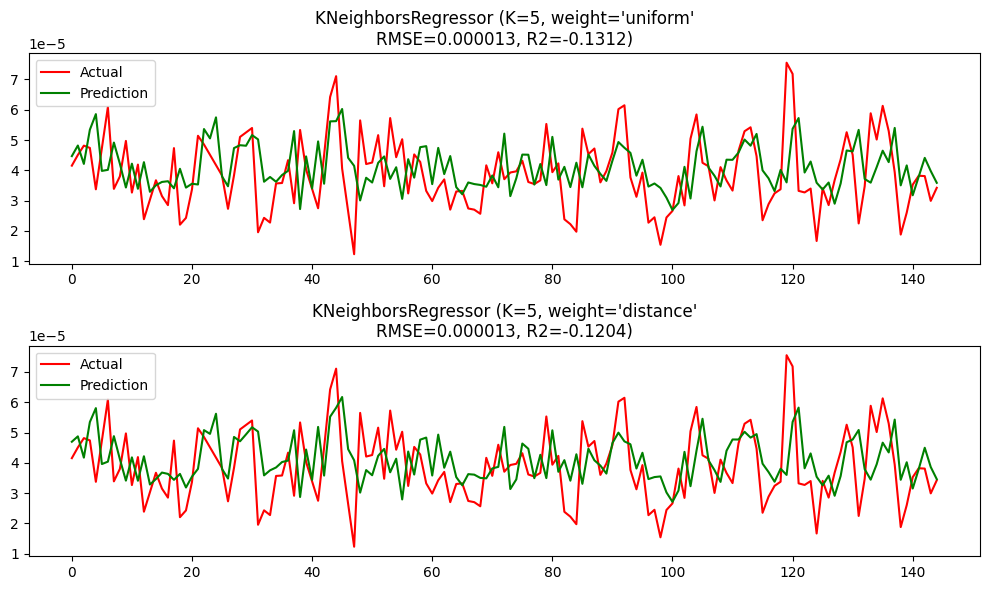

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = supervised[['NO2(t-4)', 'NO2(t-3)', 'NO2(t-2)', 'NO2(t-1)']]
y = supervised['NO2(t)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

n_neighbors = 5

plt.figure(figsize=(10, 6))

for i, weights in enumerate(['uniform', 'distance']):
    knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    plt.subplot(2, 1, i + 1)
    plt.plot(range(len(y_test)), y_test, 'red', label="Actual")
    plt.plot(range(len(y_pred)), y_pred, 'green', label="Prediction")
    plt.title(f"KNeighborsRegressor (K={n_neighbors}, weight='{weights}'\nRMSE={rmse:.6f}, R2={r2:.4f})")
    plt.legend()
    plt.tight_layout()

plt.show()